In [1]:
import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split

from config import SEED
from utils import load_image_dataset

# Entrenamiento de MobileNet

Elegimos el dataset

In [2]:
dataset = 'ciclos/mic_aug'

## Imágenes

Cargamos las imagenes desde el path del dataset elegido.

El tamaño de las imágenes es:
+ Para ciclos respiratorios: `target_size=(N_MELS, MAX_LENGTH)`
+ Para ventanas temporales: `target_size=(N_MELS, WINDOW_LENGTH)`
> Para las ventanas cuadradas se usó ``target_size=(224, 224)``, pero es una excepción.

In [3]:
train_dir = f'./data_procesada/{dataset}/imgs/train'
val_dir = f'./data_procesada/{dataset}/imgs/val'
test_dir = f'./data_procesada/{dataset}/imgs/test'

In [4]:
X_train, y_train = load_image_dataset(train_dir, target_size=(372, 128))
X_val, y_val = load_image_dataset(val_dir, target_size=(372, 128))
X_test, y_test = load_image_dataset(test_dir, target_size=(372, 128))

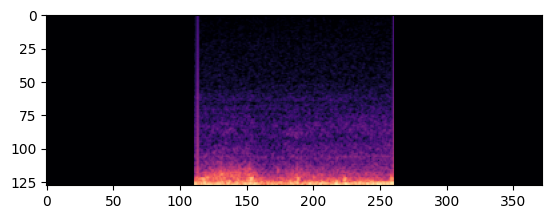

In [5]:
plt.imshow(X_train[2]);

### Definición del modelo

+ Se usa MobileNet como modelo base, con pesos preentrenados.
+ Se agregan un par de capas de augmentation.
+ Una capa de normalización como lo indica el tutorial de MobileNet.
+ Luego unas capas propias sobre el modelo base.
+ Finalmente, una capa con output binario.

In [6]:
base_model = keras.applications.MobileNetV2(
    include_top=False,
    input_shape=(128, 372, 3),
    weights="imagenet"
)

base_model.trainable = False # freezeo el modelo base

inputs = keras.Input(shape=(128, 372, 3))
traslation_layer = keras.layers.RandomTranslation(height_factor=0, width_factor=0.2, seed=SEED) # augmentacion
flip_layer = keras.layers.RandomFlip("horizontal", seed=SEED) # augmentacion
scale_layer = keras.layers.Rescaling(scale=1 / 127.5, offset=-1) # normalizacion

x = flip_layer(inputs) # augmentacion
x = traslation_layer(x) # augmentacion
x = scale_layer(x) # normalizacion
x = base_model(x, training=False) # inferencia
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(256, activation='relu')(x)
x = keras.layers.Dropout(0.3)(x)
x = keras.layers.Dense(64, activation='relu')(x)
x = keras.layers.Dropout(0.2)(x)
outputs = keras.layers.Dense(1, activation='sigmoid')(x)
model = keras.Model(inputs, outputs)

C:\Users\nazar\AppData\Local\Temp\ipykernel_3136\184640210.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


In [7]:
model.summary(show_trainable=True)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_flip (RandomFlip)    │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_translation          │ (None, 128, 372, 3)   │          0 │   -   │
│ (RandomTranslation)         │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling (Rescaling)       │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ mobilenetv2_1.00_224        │ (None, 4, 12, 1280)   │  2,257,984 │   N   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 256)           │    327,936 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 64)            │     16,448 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_1 (Dropout)         │ (None, 64)            │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_2 (Dense)             │ (None, 1)             │         65 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 2,602,433 (9.93 MB)

 Trainable params: 344,449 (1.31 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Ajuste

Definimos:
+ Learning rate (opcional).
+ Función de perdida: ``BinaryCrossentropy``.
+ Métricas auxiliares: `AUC-ROC` y `Recall`.
+ Early stopping: `patience=5`, `monitor='val_loss`, `min_delta=0.001`.

Entrenamos con un ``batch_size`` relativamente pequeño y con una cantidad de ``epochs`` alta para que se active el early stopping.

In [8]:
# lr_schedule = keras.optimizers.schedules.PolynomialDecay(
#     initial_learning_rate=1e-3,
#     decay_steps=3000,
#     end_learning_rate=1e-7,
#     power=1.0)

model.compile(
    optimizer=keras.optimizers.Adam(), #learning_rate=lr_schedule),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.AUC(), keras.metrics.Recall()]
)

In [9]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    min_delta=0.001
)

In [10]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 229s 666ms/step - auc: 0.5331 - loss: 0.6994 - recall: 0.7964 - val_auc: 0.6055 - val_loss: 0.6750 - val_recall: 0.8621
Epoch 2/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 239s 716ms/step - auc: 0.5600 - loss: 0.6801 - recall: 0.8473 - val_auc: 0.6075 - val_loss: 0.6686 - val_recall: 0.9330
Epoch 3/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 249s 744ms/step - auc: 0.5612 - loss: 0.6791 - recall: 0.8456 - val_auc: 0.6191 - val_loss: 0.6640 - val_recall: 0.9396
Epoch 4/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 294s 881ms/step - auc: 0.5877 - loss: 0.6719 - recall: 0.8581 - val_auc: 0.6337 - val_loss: 0.6634 - val_recall: 0.7420
Epoch 5/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 308s 924ms/step - auc: 0.5954 - loss: 0.6695 - recall: 0.8371 - val_auc: 0.6299 - val_loss: 0.6588 - val_recall: 0.8510
Epoch 6/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 281s 841ms/step - auc: 0.6132 - loss: 0.6639 - recall: 0.8417 - val_auc: 0.6487 - val_loss: 0.6591 - val_recall: 0.8897
Epoch 7/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 

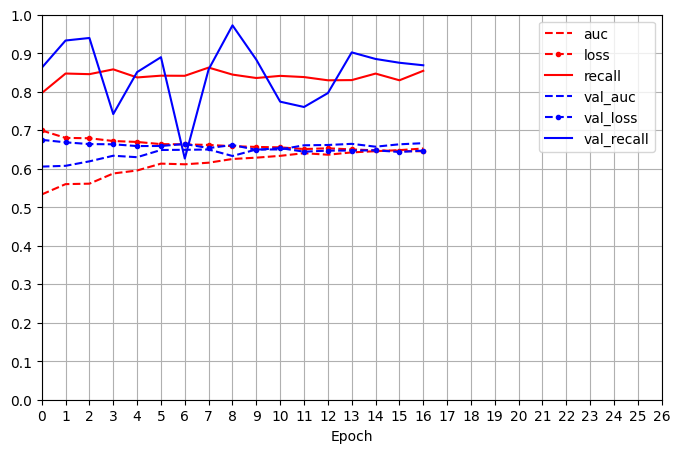

In [11]:
pd.DataFrame(history.history).plot(
    figsize=(8, 5), xlim=[0, 26], ylim=[0, 1], grid=True, xlabel="Epoch",
    style=["r--", "r--.", "r-", "b--","b--.", "b-"], xticks=range(0, 27), yticks=np.arange(0, 1.1, 0.1))
plt.show()

### Evaluación rápida

In [12]:
model.evaluate(X_test, y_test)

105/105 ━━━━━━━━━━━━━━━━━━━━ 59s 562ms/step - auc: 0.6765 - loss: 0.6368 - recall: 0.7306


[0.6368345618247986, 0.6764747500419617, 0.730567216873169]

Finalmente, guardamos el modelo para evaluación posterior

In [14]:
os.makedirs(f'./neural_network/modelos/{dataset}', exist_ok=True)

model.save(f'./neural_network/modelos/{dataset}/imgs.keras')

## Arrays

Cargamos los datos considerando el tamaño del espectrograma (igual que antes).

In [23]:
train_data = np.load(f'./data_procesada/{dataset}/train_melspectrogram.npz')
X_train = train_data['X']
y_train = train_data['y']

test_data = np.load(f'./data_procesada/{dataset}/test_melspectrogram.npz')
X_test = test_data['X']
y_test = test_data['y']

In [24]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=SEED
)

Al ser una matriz de un espectrograma tiene un solo canal (en lugar de 3, RGB).

In [26]:
X_train = X_train.reshape(-1, 128, 372, 1)
X_val = X_val.reshape(-1, 128, 372, 1)
X_test = X_test.reshape(-1, 128, 372, 1)

Repetimos ese canal 3 veces para poder usar MobileNet

In [27]:
X_train = np.repeat(X_train, 3, axis=-1)
X_val = np.repeat(X_val, 3, axis=-1)
X_test = np.repeat(X_test, 3, axis=-1)

Mismo modelo

In [28]:
base_model = keras.applications.MobileNetV2(
    include_top=False,
    input_shape=(128, 372, 3),
    weights="imagenet"
)
base_model.trainable = False

inputs = keras.Input(shape=(128, 372, 3))
translation_layer = keras.layers.RandomTranslation(height_factor=0, width_factor=0.2, seed=SEED)
flip_layer = keras.layers.RandomFlip("horizontal", seed=SEED)
scale_layer = keras.layers.Rescaling(scale=2/80, offset=1)

x = flip_layer(inputs)
x = translation_layer(x)
x = scale_layer(x)
x = base_model(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(256, activation='relu')(x)
x = keras.layers.Dropout(0.3)(x)
x = keras.layers.Dense(64, activation='relu')(x)
x = keras.layers.Dropout(0.2)(x)
outputs = keras.layers.Dense(1, activation='sigmoid')(x)

model_melspec = keras.Model(inputs, outputs)

C:\Users\nazar\AppData\Local\Temp\ipykernel_9788\182398130.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


In [29]:
model_melspec.summary(show_trainable=True)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_5 (InputLayer)  │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_flip_2 (RandomFlip)  │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ random_translation_2        │ (None, 128, 372, 3)   │          0 │   -   │
│ (RandomTranslation)         │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling_2 (Rescaling)     │ (None, 128, 372, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ mobilenetv2_1.00_224        │ (None, 4, 12, 1280)   │  2,257,984 │   N   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d_2  │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_6 (Dense)             │ (None, 256)           │    327,936 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_4 (Dropout)         │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_7 (Dense)             │ (None, 64)            │     16,448 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_5 (Dropout)         │ (None, 64)            │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_8 (Dense)             │ (None, 1)             │         65 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 2,602,433 (9.93 MB)

 Trainable params: 344,449 (1.31 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [30]:
model_melspec.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.AUC(), keras.metrics.Recall()]
)

In [31]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    min_delta=0.001
)

In [32]:
history_melspec = model_melspec.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 66s 707ms/step - auc_2: 0.5438 - loss: 0.7104 - recall_2: 0.7093 - val_auc_2: 0.5913 - val_loss: 0.6714 - val_recall_2: 0.9873
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 59s 705ms/step - auc_2: 0.5999 - loss: 0.6724 - recall_2: 0.7675 - val_auc_2: 0.6096 - val_loss: 0.6765 - val_recall_2: 0.5547
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 60s 719ms/step - auc_2: 0.6382 - loss: 0.6568 - recall_2: 0.7464 - val_auc_2: 0.6158 - val_loss: 0.6851 - val_recall_2: 0.4071
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 59s 704ms/step - auc_2: 0.6515 - loss: 0.6500 - recall_2: 0.7331 - val_auc_2: 0.6345 - val_loss: 0.6540 - val_recall_2: 0.9466
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 60s 710ms/step - auc_2: 0.6638 - loss: 0.6423 - recall_2: 0.7702 - val_auc_2: 0.6487 - val_loss: 0.6431 - val_recall_2: 0.8117
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 83s 721ms/step - auc_2: 0.6829 - loss: 0.6329 - recall_2: 0.7576 - val_auc_2: 0.6539 - val_loss: 0.6530 - val_recall_2: 0.9695
Epoch 7/50

In [33]:
model_melspec.evaluate(X_test, y_test)

27/27 ━━━━━━━━━━━━━━━━━━━━ 13s 477ms/step - auc_2: 0.7739 - loss: 0.5700 - recall_2: 0.8592


[0.5700198411941528, 0.7738553285598755, 0.8592436909675598]

In [34]:
model_melspec.save(f'./neural_network/modelos/{dataset}/melspec.keras')